In [2]:
from sklearn.svm import SVC
from model_evaluation import EvalConfig, EvalModel
from sklearn import svm
from sklearn.svm import LinearSVC
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

from feature_engineering.create_dtw_distances import create_dtw_distances

%matplotlib inline

In [16]:
old_csv_path = 'Data/features_30_sec.csv'
new_csv_path = 'Data/extra_features_30_sec.csv'
create_dtw_distances(
    old_csv_path, 
    new_csv_path, 
    downsample_factor=5, 
    feature_to_measure='rms',
    verbose=True)

Computing time series for all songs...


  0%|          | 0/999 [00:00<?, ?it/s]

Get time series for typical songs...
Computing distances...


  0%|          | 0/999 [00:00<?, ?it/s]

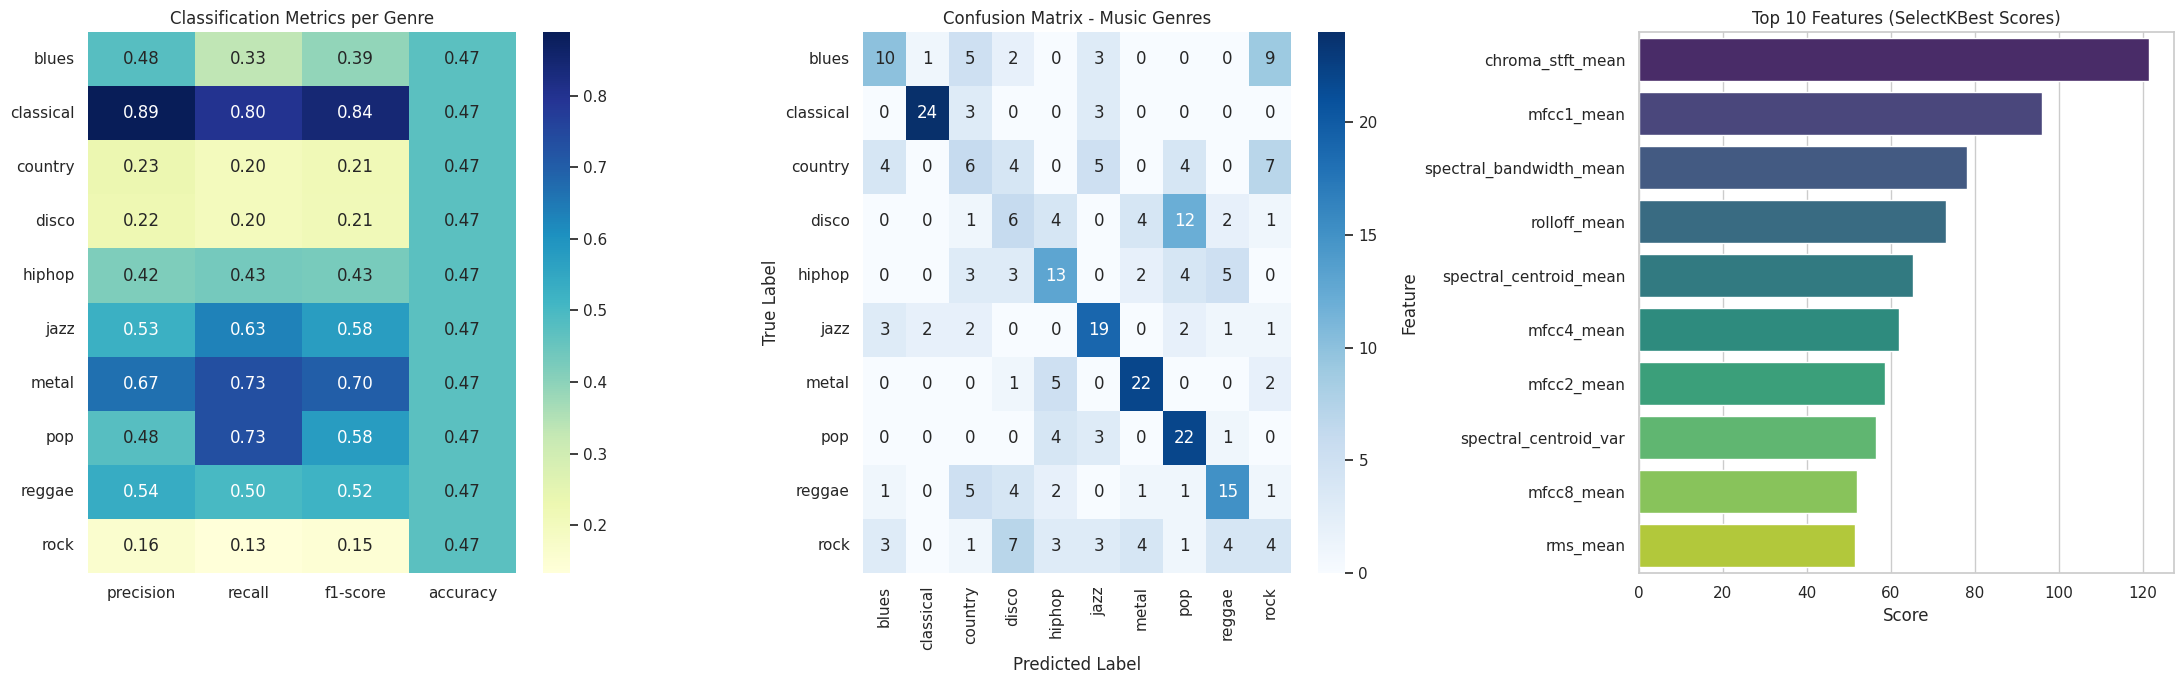

In [15]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('select_best', SelectKBest(f_classif, k=5)),
    ("clf", SVC(C=10, gamma="scale")),
])

config = EvalConfig(
    csv_path="Data/extra_features_30_sec.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

res = EvalModel(config)

res.evaluate()
res.plot_eval()